# Tutorial 10: Causal Inference on Reddit Data
## The r/fatpeoplehate Ban (June 2015)

Author: Georg Ahnert

In this notebook we estimate the causal effect of Reddit's first major deplatforming action using real data. The pipeline combines **propensity-score matching** with **difference-in-differences (DiD)** to control for selection bias and time-invariant confounders.

**Reference:** [Chandrasekharan et al. (2017): *You Can't Stay Here: The Efficacy of Reddit's 2015 Ban Examined Through Hate Speech.* Proc. CSCW.](https://dl.acm.org/doi/10.1145/3134666)

In [ ]:
!pip install scikit-learn statsmodels matplotlib pandas pyarrow -U

## The Research Question

On **June 10, 2015**, Reddit banned r/fatpeoplehate (fph) as part of its first major anti-harassment policy. We ask:

> Did being banned from r/fatpeoplehate cause users to post less hate speech in other communities?

We track behavior in three control subreddits — r/TumblrInAction, r/KotakuInAction, r/MensRights — before and after the ban for two groups:

- **Treated**: 1000 most active users who were active in fph before the ban *and* also posted in the control subreddits
- **Control**: 1000 most active users active in the control subreddits who *never* appeared in fph

Reddit data was obtained through the [arctic shift API](https://arctic-shift.photon-reddit.com/).

### Why Not a Simple Before/After Comparison?

Users self-select into communities. fph users systematically differ from typical Redditors — higher baseline hate rate, different activity patterns. A naive comparison confounds the ban's effect with those pre-existing differences. We address this in two steps:

1. **Matching** — find control users who look like the treated group on pre-ban observables.
2. **DiD** — difference out remaining time-invariant unobserved differences.

### Identification Assumptions

1. **Parallel trends** — absent the ban, treated and control users would have evolved in parallel in the control subreddits. We inspect this with an event-study plot.
2. **No anticipation** — users did not change behavior before the ban because they foresaw it. The ban was announced with little warning, making this plausible.
3. **Stable Unit Treatment Value Assumption (SUTVA)** — the treatment of one user does not affect outcomes of another. *Weakest assumption here*: if treated users started engaging with control users post-ban, that could contaminate the control group.
4. **Common support** — treated and control users overlap in covariate space. We check this with a propensity-score histogram.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.formula.api as smf
from scipy.spatial.distance import cdist
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [70]:
BAN_MONTH   = pd.Timestamp("2015-06-01")
PRE_MONTHS  = pd.date_range("2015-01-01", "2015-05-01", freq="MS")
POST_MONTHS = pd.date_range("2015-07-01", "2015-10-01", freq="MS")  # skip June
ALL_MONTHS  = list(PRE_MONTHS) + list(POST_MONTHS)

COVARIATES = [
    "pre_total_comments",
    "pre_subreddit_diversity",
    "pre_max_sub_share",
    #"pre_avg_monthly_activity",
    #"pre_hate_rate",
    "pre_score",
]

## 1. Load Preprocessed Data

The data was preprocessed by `10_label_reddit_comments.py`, which:
1. Identified treated and control users from the raw JSONL dumps
2. Classified each comment with [cardiffnlp/twitter-roberta-base-hate-latest](https://huggingface.co/cardiffnlp/twitter-roberta-base-hate-latest)
3. Aggregated to a user×month panel

In [71]:
users = pd.read_parquet("10_reddit_users.parquet")
panel = pd.read_parquet("10_reddit_panel.parquet")

print(f"Users:  {len(users)} ({users.treated.sum()} treated, {(1-users.treated).sum()} control)")
print(f"Panel:  {len(panel)} user-month observations")

Users:  2000 (1000 treated, 1000 control)
Panel:  18000 user-month observations


In [72]:
users.head()

,user_id,treated,pre_hate_rate,pre_score,pre_total_comments,pre_subreddit_diversity,pre_max_sub_share,pre_avg_monthly_activity
0,-Buzz--Killington-,0,0.045697,9.807312,1313,1,1.000000,262.6
1,-Fender-,0,0.065972,5.753472,288,3,0.517361,57.6
2,-moose-,1,0.011111,6.500000,90,2,0.877778,18.0
3,-mousey-,1,0.085106,3.914894,47,2,0.765957,9.4
4,0b3r0n,1,0.028571,7.057143,70,2,0.871429,14.0


In [73]:
panel.head(10)

,user_id,treated,month,monthly_comments,hate_rate,post
0,Vamking12,0,2015-01-01,181,0.044199,0
1,Vamking12,0,2015-02-01,2,0.000000,0
2,Vamking12,0,2015-03-01,124,0.056452,0
3,Vamking12,0,2015-04-01,16,0.000000,0
4,Vamking12,0,2015-05-01,0,0.000000,0
5,Vamking12,0,2015-07-01,3,0.000000,1
6,Vamking12,0,2015-08-01,22,0.045455,1
7,Vamking12,0,2015-09-01,1,1.000000,1
8,Vamking12,0,2015-10-01,0,0.000000,1
9,itmakessenseincontex,0,2015-01-01,109,0.018349,0


## 2. Pre-Treatment Comparison

Before any matching, let's look at how the two groups differ on the covariates. Large differences confirm the selection problem matching needs to solve.

In [74]:
users.groupby("treated")[COVARIATES].mean().T.rename(columns={0: "Control", 1: "Treated"})

treated,Control,Treated
pre_total_comments,498.280000,157.080000
pre_subreddit_diversity,1.586000,1.793000
pre_max_sub_share,0.935089,0.869909
pre_score,9.308413,8.917397


Before matching, the groups differ in *levels* — that is the selection problem. We want the trends to be roughly parallel in the pre-period, which we will verify more formally with the event study.

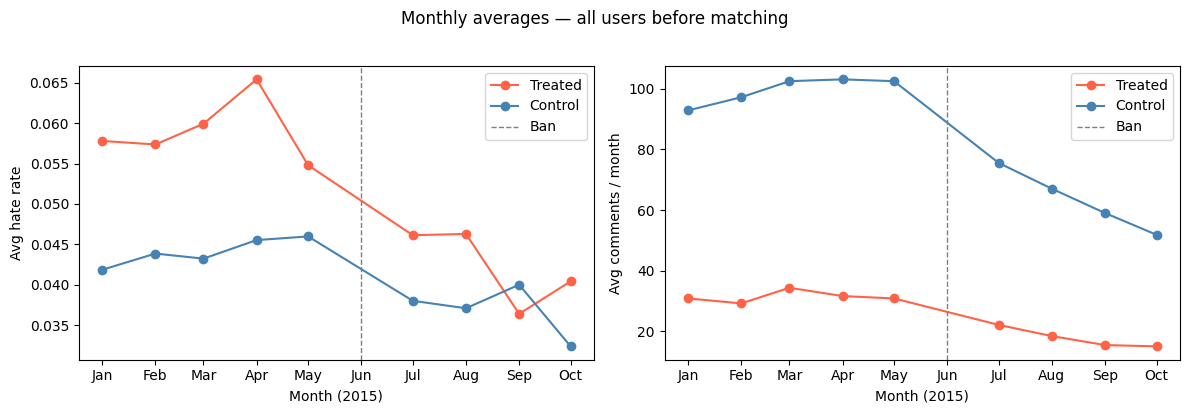

In [75]:
avg_all = panel.groupby(["month", "treated"])[["hate_rate", "monthly_comments"]].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, outcome, ylabel in zip(
    axes,
    ["hate_rate", "monthly_comments"],
    ["Avg hate rate", "Avg comments / month"],
):
    for val, color, name in [(1, "tomato", "Treated"), (0, "steelblue", "Control")]:
        d = avg_all[avg_all["treated"] == val]
        ax.plot(d["month"], d[outcome], marker="o", color=color, label=name)
    ax.axvline(BAN_MONTH, color="gray", ls="--", lw=1, label="Ban")
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.set_xlabel("Month (2015)")
    ax.set_ylabel(ylabel)
    ax.legend()
plt.suptitle("Monthly averages — all users before matching", y=1.02)
plt.tight_layout()
plt.show()

## 3. Matching Methods

Matching constructs a control group that resembles the treated group on pre-ban observables. Three methods differ in *how distance is defined*:

| Method | Distance metric | Key property |
|--------|----------------|--------------|
| **3.1 Exact** | Must share the same covariate-bin cell | Transparent; no model |
| **3.2 Propensity score** | Gap in estimated P(treated\|X) | Scalar; depends on selection model |
| **3.3 Mahalanobis** | Mahalanobis distance in covariate space | Accounts for covariance; no dimensionality reduction |

All three use **greedy 1:1 nearest-neighbour matching without replacement**. We compare their covariate balance in Section 4.

### 3.1 Exact (Coarsened) Matching

**Coarsened Exact Matching (CEM)** discretises each continuous covariate into bins, then requires that a treated user and their match fall in the *exact same bin on every covariate simultaneously*. Within that cell, the nearest neighbour by standardised Euclidean distance is chosen.

Pros: fully transparent, no model required.  
Cons: with many covariates, cells become sparse and some treated users find no match — the **match rate** tells us how well the covariate space overlaps.

In [100]:
def match_exact(users, n_bins=3):
    """
    Coarsened Exact Matching (CEM): median-split each covariate into bins,
    then match nearest neighbour (L2 on standardised covariates) within the
    same covariate cell. Unmatched treated users (empty cell) are dropped.
    """
    df    = users.reset_index(drop=True).copy()
    X_std = StandardScaler().fit_transform(df[COVARIATES])

    bin_cols = []
    for c in COVARIATES:
        col = f"_b_{c}"
        df[col] = pd.qcut(df[c], n_bins, labels=False, duplicates="drop")
        bin_cols.append(col)
    df["_cell"] = df[bin_cols].astype(str).agg("-".join, axis=1)

    treated   = df[df["treated"] == 1].sample(frac=1, random_state=42)
    available = df[df["treated"] == 0].copy()
    matches   = []

    for row_i, t in treated.iterrows():
        cands = available[available["_cell"] == t["_cell"]]
        if cands.empty:
            continue
        dists = np.linalg.norm(X_std[cands.index] - X_std[row_i], axis=1)
        best  = cands.index[dists.argmin()]
        matches.append((t["user_id"], available.loc[best, "user_id"]))
        available = available.drop(best)

    ids = {u for pair in matches for u in pair}
    return (df[df["user_id"].isin(ids)]
            .drop(columns=bin_cols + ["_cell"])
            .reset_index(drop=True),
            matches)


matched_exact, _ = match_exact(users)
print(f"Exact matching:  {len(_)} matched pairs")

Exact matching:  294 matched pairs


### 3.2 Propensity Score Matching

We estimate $P(\text{treated}=1 \mid X)$ via logistic regression. The score summarises all covariates into a single number we can use for matching.

Each treated user is then matched to the nearest available control user whose **logit** propensity score is within a caliper of 0.1 standard deviations (greedy 1:1, without replacement).

In [77]:
X = StandardScaler().fit_transform(users[COVARIATES])
y = users["treated"].values
pscore = LogisticRegression(max_iter=1000).fit(X, y).predict_proba(X)[:, 1]

First, check **common support**: if the propensity score distributions barely overlap, the two groups are too different to match well.

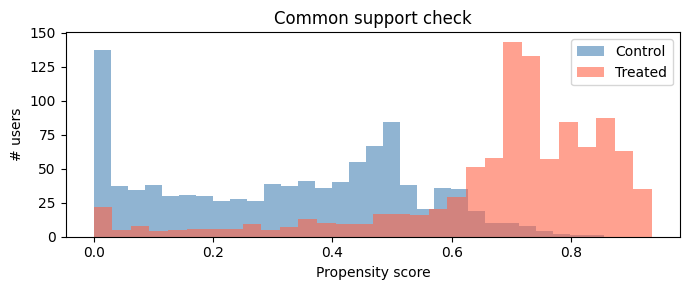

In [78]:
fig, ax = plt.subplots(figsize=(7, 3))
for val, color, name in [(0, "steelblue", "Control"), (1, "tomato", "Treated")]:
    ax.hist(pscore[y == val], bins=30, alpha=0.6, color=color, label=name)
ax.set_xlabel("Propensity score")
ax.set_ylabel("# users")
ax.set_title("Common support check")
ax.legend()
plt.tight_layout()
plt.show()

In [94]:
def match_users(users, pscore, caliper=0.1):
    df = users.copy()
    df["pscore"]  = pscore
    df["logit_p"] = np.log(pscore / (1 - pscore))
    threshold = caliper * df["logit_p"].std()

    treated   = df[df["treated"] == 1].sample(frac=1, random_state=42)
    available = df[df["treated"] == 0].set_index("user_id")
    matches   = []

    for _, t in treated.iterrows():
        if available.empty:
            break
        diffs = (available["logit_p"] - t["logit_p"]).abs()
        best  = diffs.idxmin()
        if diffs[best] <= threshold:
            matches.append((t["user_id"], best))
            available = available.drop(best)

    ids = {u for pair in matches for u in pair}
    return df[df["user_id"].isin(ids)].reset_index(drop=True), matches


matched_pscore, _ = match_users(users, pscore)
print(f"Propensity score: {len(_)} matched pairs")

Propensity score: 313 matched pairs


### 3.3 Mahalanobis Distance Matching

**Mahalanobis distance** measures separation in covariate space while accounting for the scale and correlation structure of the covariates:

$$d_M(x_i, x_j) = \sqrt{(x_i - x_j)^\top \Sigma^{-1} (x_i - x_j)}$$

where $\Sigma$ is the pooled covariance matrix. This corrects for the fact that covariates on different scales (e.g., `pre_total_comments` vs `pre_max_sub_share`) would otherwise contribute unequally.

Unlike the propensity score, no model of treatment selection is required. Unlike standardised Euclidean distance, correlated covariates are not double-counted.

In [109]:
def match_mahalanobis(users, caliper=0.15):
    """
    Mahalanobis distance matching: nearest neighbour in the covariate space
    scaled by the pooled inverse covariance matrix. Unlike propensity-score
    matching, no dimensionality reduction is required; unlike standardised
    Euclidean distance, correlations between covariates are accounted for.
    """
    df  = users.reset_index(drop=True).copy()
    X   = df[COVARIATES].values.astype(float)
    VI  = np.linalg.inv(np.cov(X.T))   # inverse covariance matrix

    treated   = df[df["treated"] == 1].sample(frac=1, random_state=42)
    available = df[df["treated"] == 0].copy()
    matches   = []

    for row_i, t in treated.iterrows():
        if available.empty:
            break
        dists = cdist([X[row_i]], X[available.index], metric="mahalanobis", VI=VI)[0]
        best_pos = dists.argmin()
        if caliper is None or dists[best_pos] <= caliper:
            best_id = available.iloc[best_pos]["user_id"]
            matches.append((t["user_id"], best_id))
            available = available.drop(available.index[best_pos])

    ids = {u for pair in matches for u in pair}
    return df[df["user_id"].isin(ids)].reset_index(drop=True), matches


matched_mah, _ = match_mahalanobis(users)
print(f"Mahalanobis:      {len(_)} matched pairs")

Mahalanobis:      159 matched pairs


## 4. Balance Check

The **standardized mean difference (SMD)** measures covariate imbalance in units of pooled standard deviations:

$$\text{SMD} = \frac{\bar{X}_{\text{treated}} - \bar{X}_{\text{control}}}{\sqrt{(s^2_{\text{treated}} + s^2_{\text{control}}) / 2}}$$

Rule of thumb: $|\text{SMD}| < 0.1$ = good balance. Comparing all three methods side by side reveals the balance–sample-size trade-off: exact matching is strict but may drop many treated users; propensity score and Mahalanobis retain more pairs.

In [108]:
def smd(df, covariates):
    rows = []
    for c in covariates:
        t    = df.loc[df.treated == 1, c]
        ctrl = df.loc[df.treated == 0, c]
        sd   = np.sqrt((t.var() + ctrl.var()) / 2)
        rows.append({"covariate": c, "smd": (t.mean() - ctrl.mean()) / sd})
    return pd.DataFrame(rows).set_index("covariate")


bal = pd.DataFrame({
    "unmatched": smd(users,          COVARIATES)["smd"],
    "exact":     smd(matched_exact,  COVARIATES)["smd"],
    "pscore":    smd(matched_pscore, COVARIATES)["smd"],
    "mahal":     smd(matched_mah,    COVARIATES)["smd"],
})
bal.style.format("{:+.3f}").background_gradient(cmap="RdYlGn_r", vmin=-0.5, vmax=0.5)

,unmatched,exact,pscore,mahal
covariate,,,,
pre_total_comments,-0.781,-0.006,-0.129,-0.056
pre_subreddit_diversity,+0.293,-0.005,-0.373,+0.000
pre_max_sub_share,-0.436,-0.031,+0.369,-0.004
pre_score,-0.050,-0.021,+0.022,-0.012


Choose which matched sample to carry forward into the panel analysis. The propensity-score sample is the default; swap in the others to see how the DiD estimate changes.

In [110]:
# Options: matched_exact, matched_pscore, matched_mah
matched_users = matched_mah

## 5. Monthly Outcome Panel

We keep only the matched users in the panel and plot raw monthly averages to get a first look at the trajectories.

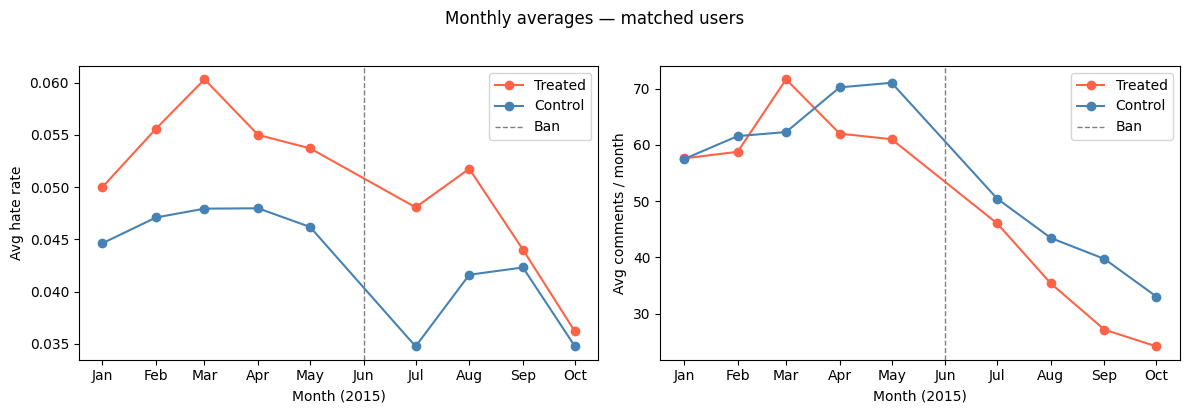

In [111]:
matched_panel = panel[panel["user_id"].isin(matched_users["user_id"])].copy()

avg = matched_panel.groupby(["month", "treated"])[["hate_rate", "monthly_comments"]].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, outcome, ylabel in zip(
    axes,
    ["hate_rate", "monthly_comments"],
    ["Avg hate rate", "Avg comments / month"],
):
    for val, color, name in [(1, "tomato", "Treated"), (0, "steelblue", "Control")]:
        d = avg[avg["treated"] == val]
        ax.plot(d["month"], d[outcome], marker="o", color=color, label=name)
    ax.axvline(BAN_MONTH, color="gray", ls="--", lw=1, label="Ban")
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.set_xlabel("Month (2015)")
    ax.set_ylabel(ylabel)
    ax.legend()
plt.suptitle("Monthly averages — matched users", y=1.02)
plt.tight_layout()
plt.show()

## 6. Difference-in-Differences

In [112]:
# Naive post-period comparison (ignores pre-period differences — biased)
post = matched_panel[matched_panel["post"] == 1]
for outcome, fmt in [("hate_rate", ".4f"), ("monthly_comments", ".2f")]:
    naive = post.groupby("treated")[outcome].mean()
    print(f"Naive post-period mean diff  ({outcome}): {naive[1] - naive[0]:+{fmt}}")
print("(Biased when pre-period levels differ between groups)")

Naive post-period mean diff  (hate_rate): +0.0066
Naive post-period mean diff  (monthly_comments): -8.47
(Biased when pre-period levels differ between groups)


The DiD estimator uses **two-way fixed effects** (user FE absorbs time-invariant individual differences; month FE absorbs common time trends):

$$Y_{it} = \alpha_i + \gamma_t + \delta \cdot (\text{treated}_i \times \text{post}_t) + \varepsilon_{it}$$

$\hat{\delta}$ is the ATT (average treatment effect on the treated). Standard errors are clustered at the user level.

In [113]:
def estimate_did(panel, outcome):
    df = panel.assign(
        did       = panel["treated"] * panel["post"],
        month_str = panel["month"].astype(str),
    )
    formula = f"{outcome} ~ did + C(user_id) + C(month_str)"
    return smf.ols(formula, data=df).fit(
        cov_type="cluster", cov_kwds={"groups": df["user_id"]}
    )


for outcome in ["hate_rate", "monthly_comments"]:
    m = estimate_did(matched_panel, outcome)
    coef, se = m.params["did"], m.bse["did"]
    print(f"{outcome}")
    print(f"  δ̂ = {coef:+.4f}  SE = {se:.4f}  "
          f"95% CI [{coef - 1.96*se:+.4f}, {coef + 1.96*se:+.4f}]")

hate_rate
  δ̂ = -0.0015  SE = 0.0057  95% CI [-0.0127, +0.0096]
monthly_comments
  δ̂ = -6.1651  SE = 6.5835  95% CI [-19.0688, +6.7386]


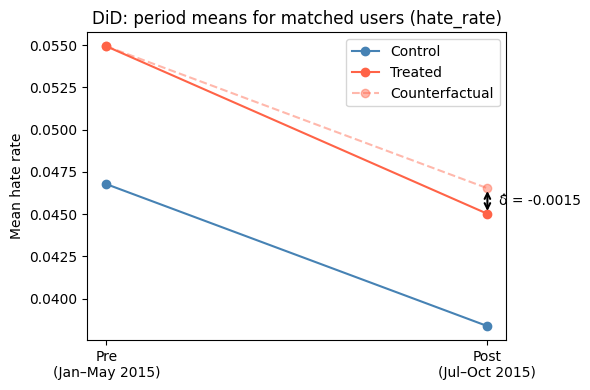

In [114]:
# Classic 2x2 DiD diagram for hate_rate
pm = (matched_panel.groupby(["treated", "post"])["hate_rate"]
      .mean().reset_index())

ctrl_pre       = pm.query("treated==0 and post==0")["hate_rate"].values[0]
ctrl_post      = pm.query("treated==0 and post==1")["hate_rate"].values[0]
treat_pre      = pm.query("treated==1 and post==0")["hate_rate"].values[0]
treat_post     = pm.query("treated==1 and post==1")["hate_rate"].values[0]
counterfactual = treat_pre + (ctrl_post - ctrl_pre)
did_est        = treat_post - counterfactual

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([0, 1], [ctrl_pre,  ctrl_post],      "o-",  color="steelblue", label="Control")
ax.plot([0, 1], [treat_pre, treat_post],     "o-",  color="tomato",    label="Treated")
ax.plot([0, 1], [treat_pre, counterfactual], "o--", color="tomato",    label="Counterfactual", alpha=0.45)
ax.annotate("", xy=(1, treat_post), xytext=(1, counterfactual),
            arrowprops=dict(arrowstyle="<->", color="black", lw=1.5))
ax.text(1.03, (treat_post + counterfactual) / 2,
        f"δ̂ = {did_est:+.4f}", va="center", fontsize=10)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Pre\n(Jan–May 2015)", "Post\n(Jul–Oct 2015)"])
ax.set_ylabel("Mean hate rate")
ax.set_title("DiD: period means for matched users (hate_rate)")
ax.legend()
plt.tight_layout()
plt.show()

## Discussion

Use the results above to work through the following questions:

1. **Balance** — Did matching reduce the SMDs? Are all post-matching SMDs below 0.1? What happens if you tighten the caliper to 0.1?

2. **Common support** — Does the propensity-score histogram show sufficient overlap? What does poor overlap imply for the validity of the matching?

3. **Naive vs. DiD** — In which direction does the naive estimator differ from the DiD estimate, and why? Which pre-existing difference drives the bias?

4. **SUTVA** — If banned fph users started engaging more with TIA/KIA/MR users after the ban (e.g., seeking new communities), how would that affect $\hat{\delta}$? Over- or under-estimate?

5. **Outcome interpretation** — `hate_rate` is based on a model (`cardiffnlp/twitter-roberta-base-hate-latest`), not human labels. How might model errors (false positives/negatives) bias the DiD estimate? Does the direction of any bias depend on whether model errors are correlated with treatment?